# PCA with Sklearn vs. Numpy

They return different Z results, but they are only different numerically. Geometrically they are the same

In [127]:
import numpy as np

Here's the data matrix I'll do PCA on using both numpy and sklearn to compare results.

In [128]:
X = np.array([[2,0],
              [0,2],
              [2,2]])

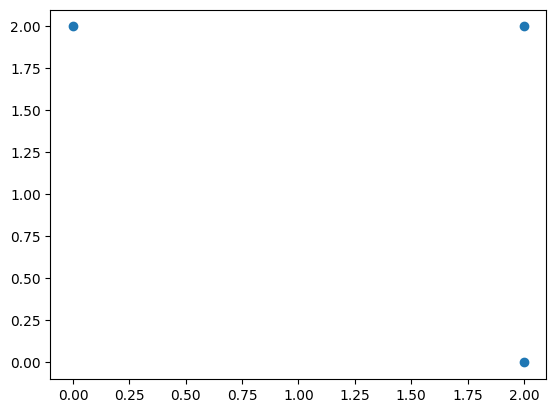

In [129]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1])
plt.show()

# SKlearn

In [130]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Z = pca.fit_transform(X)


In [131]:
Z

array([[-1.41421356e+00, -4.71404521e-01],
       [ 1.41421356e+00, -4.71404521e-01],
       [ 9.19738868e-17,  9.42809042e-01]])

In [132]:
print(pca.components_)


[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


In [133]:
print(pca.explained_variance_)


[2.         0.66666667]


In [134]:
print(pca.singular_values_)


[2.         1.15470054]


# Numpy

In [135]:
X_c = X - X.mean(axis=0)

right = X_c.T @ X_c

right


array([[ 2.66666667, -1.33333333],
       [-1.33333333,  2.66666667]])

In [136]:
X_c

array([[ 0.66666667, -1.33333333],
       [-1.33333333,  0.66666667],
       [ 0.66666667,  0.66666667]])

In [137]:
eigenvalues, eigenvectors = np.linalg.eigh(right)

eigenvalues

array([1.33333333, 4.        ])

In [138]:
eigenvectors


array([[-0.70710678, -0.70710678],
       [-0.70710678,  0.70710678]])

In [139]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
V = eigenvectors
V

array([[-0.70710678, -0.70710678],
       [ 0.70710678, -0.70710678]])

In [140]:


Z2 = X_c @ V
Z2

array([[-1.41421356e+00,  4.71404521e-01],
       [ 1.41421356e+00,  4.71404521e-01],
       [ 1.53289811e-17, -9.42809042e-01]])

# Conclusion

So Z from sklearn was 
```
[[-1.41421356e+00, -4.71404521e-01],
[ 1.41421356e+00, -4.71404521e-01],
[ 9.19738868e-17,  9.42809042e-01]]
```


and from numpy it is 
```
[[-1.41421356e+00,  4.71404521e-01],
[ 1.41421356e+00,  4.71404521e-01],
[ 1.53289811e-17, -9.42809042e-01]]
```


Even though they're different numbers, they are actually the same.

Verifying they're the same correct PCA below.

In [141]:
np.allclose(X_c, Z2 @ V.T)


True

In [142]:
V.T @ V

array([[ 1.00000000e+00, -2.23711432e-17],
       [-2.23711432e-17,  1.00000000e+00]])

In [143]:
Z2.T @ Z2

array([[4.00000000e+00, 2.17253608e-17],
       [2.17253608e-17, 1.33333333e+00]])

In [144]:
from scipy.spatial.distance import pdist

np.allclose(pdist(X_c), pdist(Z))


True

In [145]:
np.allclose(np.abs(Z2), np.abs(Z))


True

Sklearn uses U in SVD formula X = UΣV , while I didn't in Numpy. And U isn't needed anyways for PCA.



Sign flips happen internally for calculations but the subspace is the same.